<a href="https://colab.research.google.com/github/Rasmy-r7/Research/blob/main/TinyBERT%26CodeBERT_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#═══════════════════════════════════════════════════════════════
# STEP 1: Install required packages
# Run this first, then restart runtime
#═══════════════════════════════════════════════════════════════
import os
os.environ["WANDB_DISABLED"] = "true"

!pip uninstall transformers accelerate peft -y -q
!pip install transformers==4.40.0 accelerate==0.27.2 -q

print("✅ Installation complete!")
print("   → Runtime → Restart Session → OK")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.6/137.6 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.0/9.0 MB 55.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 280.0/280.0 kB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 31.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 91.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sentence-transformers 5.5.1 requires transformers<6.0.0,>=4.41.0, but you have transformers 4.40.0 which is incompatible.
✅ Installation complete!
   → Runtime → Restart Session → OK


In [2]:
#═══════════════════════════════════════════════════════════════
# STEP 2: Import all libraries
# Run this immediately after restarting runtime
#═══════════════════════════════════════════════════════════════
import os, random, json
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoTokenizer, AutoModel,
    get_cosine_schedule_with_warmup
)
from sklearn.metrics import (
    accuracy_score, precision_score,
    recall_score, f1_score,
    confusion_matrix, classification_report
)
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from tqdm import tqdm

os.environ["WANDB_DISABLED"] = "true"

# ── Reproducibility ──────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ All libraries imported!")
print(f"   Device : {device}")
if not torch.cuda.is_available():
    print("   ⚠️  No GPU! → Runtime → Change Runtime Type → T4 GPU")

✅ All libraries imported!
   Device : cuda


In [3]:
#═══════════════════════════════════════════════════════════════
# STEP 3: Upload and load all 3 CSV files
# Required columns: text, priority, priority_id
# priority     : High / Medium / Low  (string)
# priority_id  : 0 / 1 / 2           (integer)
#═══════════════════════════════════════════════════════════════
from google.colab import files

print("Upload your 3 CSV files:")
print("   1. train_combined.csv")
print("   2. val_combined.csv")
print("   3. test_combined.csv")

uploaded = files.upload()

train_df = pd.read_csv("train_combined.csv")
val_df   = pd.read_csv("val_combined.csv")
test_df  = pd.read_csv("test_combined.csv")

# ── Validate columns ─────────────────────────────────────────
for name, df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    assert 'text'        in df.columns, f"❌ Missing 'text' column in {name}"
    assert 'priority_id' in df.columns, f"❌ Missing 'priority_id' column in {name}"
    assert 'priority'    in df.columns, f"❌ Missing 'priority' column in {name}"

# ── Label config ─────────────────────────────────────────────
LABEL_MAP   = {'High': 0, 'Medium': 1, 'Low': 2}
INV_LABEL   = {0: 'High', 1: 'Medium', 2: 'Low'}
NUM_CLASSES = 3

# Ensure priority_id is integer
for df in [train_df, val_df, test_df]:
    df['priority_id'] = df['priority_id'].astype(int)

print(f"\n✅ All files loaded!")
print(f"   Train : {len(train_df):,} rows")
print(f"   Val   : {len(val_df):,} rows")
print(f"   Test  : {len(test_df):,} rows")
print(f"\n   Label distribution (train):")
print(train_df['priority'].value_counts().to_string())

Upload your 3 CSV files:
   1. train_combined.csv
   2. val_combined.csv
   3. test_combined.csv


Saving test_combined.csv to test_combined.csv
Saving val_combined.csv to val_combined.csv
Saving train_combined.csv to train_combined.csv

✅ All files loaded!
   Train : 23,274 rows
   Val   : 2,909 rows
   Test  : 2,910 rows

   Label distribution (train):
priority
Medium    9430
High      8550
Low       5294


In [4]:
#═══════════════════════════════════════════════════════════════
# STEP 4 FIXED: Load TinyBERT + CodeBERT
# KEY CHANGE: Unfreeze last 2 layers of both models
# Frozen backbones = generic embeddings = stuck accuracy
# Unfreezing last layers = task-specific fine-tuning
#═══════════════════════════════════════════════════════════════
TINYBERT_NAME = "huawei-noah/TinyBERT_General_4L_312D"
CODEBERT_NAME = "microsoft/codebert-base"

print("Loading TinyBERT...")
tinybert_tokenizer = AutoTokenizer.from_pretrained(TINYBERT_NAME)
tinybert_model     = AutoModel.from_pretrained(TINYBERT_NAME).to(device)

print("Loading CodeBERT...")
codebert_tokenizer = AutoTokenizer.from_pretrained(CODEBERT_NAME)
codebert_model     = AutoModel.from_pretrained(CODEBERT_NAME).to(device)

# ── Freeze all layers first ──────────────────────────────────
for m in [tinybert_model, codebert_model]:
    for param in m.parameters():
        param.requires_grad = False

# ── Unfreeze last 2 layers of TinyBERT ──────────────────────
# TinyBERT has 4 layers (0,1,2,3) → unfreeze layers 2 and 3
for name, param in tinybert_model.named_parameters():
    if any(f"layer.{i}" in name for i in [2, 3]):
        param.requires_grad = True

# ── Unfreeze last 2 layers of CodeBERT ──────────────────────
# CodeBERT has 12 layers (0..11) → unfreeze layers 10 and 11
for name, param in codebert_model.named_parameters():
    if any(f"layer.{i}" in name for i in [10, 11]):
        param.requires_grad = True

# Embedding dimensions
TINYBERT_DIM = 312
CODEBERT_DIM = 768
FUSED_DIM    = TINYBERT_DIM + CODEBERT_DIM   # 1080

# Count trainable params
tiny_trainable = sum(p.numel() for p in tinybert_model.parameters()
                     if p.requires_grad)
code_trainable = sum(p.numel() for p in codebert_model.parameters()
                     if p.requires_grad)

print(f"\n✅ Models loaded — last 2 layers UNFROZEN!")
print(f"   TinyBERT trainable : {tiny_trainable:,} params (layers 2-3)")
print(f"   CodeBERT trainable : {code_trainable:,} params (layers 10-11)")
print(f"   Fused dim          : {FUSED_DIM}")

Loading TinyBERT...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/409 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]


✅ Models loaded — last 2 layers UNFROZEN!
   TinyBERT trainable : 2,284,368 params (layers 2-3)
   CodeBERT trainable : 14,175,744 params (layers 10-11)
   Fused dim          : 1080


In [5]:
#═══════════════════════════════════════════════════════════════
# STEP 5: FusionDataset
# Tokenizes each text TWICE:
#   → once with TinyBERT tokenizer
#   → once with CodeBERT tokenizer
# Both tokenizers have different vocabularies
# Uses priority_id as the integer label
#═══════════════════════════════════════════════════════════════
MAX_LENGTH = 128

class FusionDataset(Dataset):
    def __init__(self, dataframe, tiny_tokenizer,
                 code_tokenizer, max_length=MAX_LENGTH):
        self.texts          = dataframe['text'].tolist()
        self.labels         = dataframe['priority_id'].tolist()
        self.tiny_tokenizer = tiny_tokenizer
        self.code_tokenizer = code_tokenizer
        self.max_length     = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])

        # TinyBERT tokenization
        tiny_enc = self.tiny_tokenizer(
            text,
            max_length     = self.max_length,
            padding        = 'max_length',
            truncation     = True,
            return_tensors = 'pt'
        )
        # CodeBERT tokenization
        code_enc = self.code_tokenizer(
            text,
            max_length     = self.max_length,
            padding        = 'max_length',
            truncation     = True,
            return_tensors = 'pt'
        )

        return {
            'tiny_input_ids'     : tiny_enc['input_ids'].squeeze(0),
            'tiny_attention_mask': tiny_enc['attention_mask'].squeeze(0),
            'code_input_ids'     : code_enc['input_ids'].squeeze(0),
            'code_attention_mask': code_enc['attention_mask'].squeeze(0),
            'label'              : torch.tensor(
                                       self.labels[idx], dtype=torch.long
                                   )
        }

# Build datasets
BATCH_SIZE    = 32

train_dataset = FusionDataset(train_df, tinybert_tokenizer, codebert_tokenizer)
val_dataset   = FusionDataset(val_df,   tinybert_tokenizer, codebert_tokenizer)
test_dataset  = FusionDataset(test_df,  tinybert_tokenizer, codebert_tokenizer)

# Build dataloaders
train_loader  = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                           shuffle=True,  num_workers=2, pin_memory=True)
val_loader    = DataLoader(val_dataset,   batch_size=64,
                           shuffle=False, num_workers=2, pin_memory=True)
test_loader   = DataLoader(test_dataset,  batch_size=64,
                           shuffle=False, num_workers=2, pin_memory=True)

print(f"✅ Datasets and DataLoaders ready!")
print(f"   Train : {len(train_dataset):,} samples  |  {len(train_loader)} batches")
print(f"   Val   : {len(val_dataset):,} samples  |  {len(val_loader)} batches")
print(f"   Test  : {len(test_dataset):,} samples  |  {len(test_loader)} batches")
print(f"   Max length per tokenizer : {MAX_LENGTH} tokens")

✅ Datasets and DataLoaders ready!
   Train : 23,274 samples  |  728 batches
   Val   : 2,909 samples  |  46 batches
   Test  : 2,910 samples  |  46 batches
   Max length per tokenizer : 128 tokens


In [6]:
#═══════════════════════════════════════════════════════════════
# STEP 6 FIXED: Deeper Fusion Classifier
# KEY CHANGES:
#   Added attention pooling — better than just [CLS] token
#   Added BatchNorm — stabilises training
#   Added more dropout — prevents overfitting
#   Deeper layers — more capacity to learn boundaries
#═══════════════════════════════════════════════════════════════
class TinyBERTCodeBERTFusionClassifier(nn.Module):
    def __init__(self, tiny_dim=312, code_dim=768,
                 num_classes=3,
                 dropout1=0.4, dropout2=0.3, dropout3=0.2):
        super().__init__()

        fused_dim = tiny_dim + code_dim   # 1080

        # ── Projection layers (compress each embedding first) ─
        # Projecting before concat helps model learn
        # separate importance for each backbone
        self.tiny_proj = nn.Sequential(
            nn.Linear(tiny_dim, 256),
            nn.LayerNorm(256),
            nn.GELU(),
            nn.Dropout(0.2)
        )
        self.code_proj = nn.Sequential(
            nn.Linear(code_dim, 512),
            nn.LayerNorm(512),
            nn.GELU(),
            nn.Dropout(0.2)
        )

        # After projection: 256 + 512 = 768
        proj_dim = 256 + 512

        # ── Classifier head ───────────────────────────────────
        self.classifier = nn.Sequential(
            nn.Linear(proj_dim, 512),
            nn.LayerNorm(512),
            nn.GELU(),
            nn.Dropout(dropout1),

            nn.Linear(512, 256),
            nn.LayerNorm(256),
            nn.GELU(),
            nn.Dropout(dropout2),

            nn.Linear(256, 128),
            nn.LayerNorm(128),
            nn.GELU(),
            nn.Dropout(dropout3),

            nn.Linear(128, num_classes)
        )

        # ── Residual: proj_dim → 512 ─────────────────────────
        self.residual_proj = nn.Linear(proj_dim, 512)

        self._init_weights()

    def _init_weights(self):
        for module in self.modules():
            if isinstance(module, nn.Linear):
                nn.init.xavier_uniform_(module.weight)
                nn.init.zeros_(module.bias)

    def forward(self, tiny_emb, code_emb):
        # 1. Project each embedding independently
        tiny_out = self.tiny_proj(tiny_emb)   # (B, 256)
        code_out = self.code_proj(code_emb)   # (B, 512)

        # 2. Concatenate projected embeddings
        fused    = torch.cat([tiny_out, code_out], dim=-1)  # (B, 768)

        # 3. Residual path
        residual = self.residual_proj(fused)  # (B, 512)

        # 4. First classifier layer + residual add
        x = self.classifier[0](fused)         # Linear → 512
        x = self.classifier[1](x)             # LayerNorm
        x = self.classifier[2](x)             # GELU
        x = self.classifier[3](x + residual)  # Dropout + residual

        # 5. Rest of classifier
        for layer in self.classifier[4:]:
            x = layer(x)

        return x


classifier = TinyBERTCodeBERTFusionClassifier(
    tiny_dim    = TINYBERT_DIM,
    code_dim    = CODEBERT_DIM,
    num_classes = NUM_CLASSES
).to(device)

total_params     = sum(p.numel() for p in classifier.parameters())
trainable_params = sum(p.numel() for p in classifier.parameters()
                       if p.requires_grad)

print("✅ Improved Fusion Classifier built!")
print(f"   TinyBERT({TINYBERT_DIM}) → proj(256)")
print(f"   CodeBERT({CODEBERT_DIM}) → proj(512)")
print(f"   Concat(768) → 512 → 256 → 128 → {NUM_CLASSES}")
print(f"   Total params     : {total_params:,}")
print(f"   Trainable params : {trainable_params:,}")

✅ Improved Fusion Classifier built!
   TinyBERT(312) → proj(256)
   CodeBERT(768) → proj(512)
   Concat(768) → 512 → 256 → 128 → 3
   Total params     : 1,429,251
   Trainable params : 1,429,251


In [7]:
#═══════════════════════════════════════════════════════════════
# STEP 7 FIXED: Optimizer with differential learning rates
# KEY CHANGES:
#   Backbone layers  → very low LR (2e-5) — fine-tune gently
#   Classifier head  → higher LR (3e-4)  — learn faster
#   More epochs (25) — give model time to converge
#   Patience 7       — don't stop too early
#═══════════════════════════════════════════════════════════════
from sklearn.utils.class_weight import compute_class_weight

# ── Class weights ────────────────────────────────────────────
raw_weights   = compute_class_weight(
    class_weight = 'balanced',
    classes      = np.array([0, 1, 2]),
    y            = train_df['priority_id'].values
)
class_weights = torch.tensor(raw_weights, dtype=torch.float).to(device)

print("Class weights:")
print(f"   High   (0) : {raw_weights[0]:.4f}")
print(f"   Medium (1) : {raw_weights[1]:.4f}")
print(f"   Low    (2) : {raw_weights[2]:.4f}")

# ── Focal Loss ───────────────────────────────────────────────
class FocalLoss(nn.Module):
    def __init__(self, weight=None, gamma=2.0, label_smoothing=0.1):
        super().__init__()
        self.weight          = weight
        self.gamma           = gamma
        self.label_smoothing = label_smoothing

    def forward(self, logits, labels):
        ce    = F.cross_entropy(
                    logits, labels,
                    weight          = self.weight,
                    label_smoothing = self.label_smoothing,
                    reduction       = 'none'
                )
        pt    = torch.exp(-ce)
        focal = ((1 - pt) ** self.gamma) * ce
        return focal.mean()

criterion = FocalLoss(
    weight          = class_weights,
    gamma           = 2.0,
    label_smoothing = 0.1
)

# ── Differential learning rates ──────────────────────────────
# Backbone layers: fine-tune gently with very low LR
# Classifier head: higher LR — learns the task mapping
EPOCHS       = 25
BACKBONE_LR  = 2e-5    # for unfrozen TinyBERT + CodeBERT layers
HEAD_LR      = 2e-4    # for classifier head
WEIGHT_DECAY = 0.01

optimizer = torch.optim.AdamW([
    # TinyBERT unfrozen layers
    {'params': [p for p in tinybert_model.parameters()
                if p.requires_grad],
     'lr': BACKBONE_LR},
    # CodeBERT unfrozen layers
    {'params': [p for p in codebert_model.parameters()
                if p.requires_grad],
     'lr': BACKBONE_LR},
    # Classifier head
    {'params': classifier.parameters(),
     'lr': HEAD_LR},
], weight_decay=WEIGHT_DECAY)

# ── Cosine schedule with warmup ──────────────────────────────
total_steps  = len(train_loader) * EPOCHS
warmup_steps = int(0.1 * total_steps)

scheduler = get_cosine_schedule_with_warmup(
    optimizer,
    num_warmup_steps   = warmup_steps,
    num_training_steps = total_steps
)

print(f"\n✅ Optimizer configured!")
print(f"   Backbone LR  : {BACKBONE_LR}  (unfrozen layers)")
print(f"   Head LR      : {HEAD_LR}  (classifier)")
print(f"   Epochs       : {EPOCHS}")
print(f"   Warmup steps : {warmup_steps}")

Class weights:
   High   (0) : 0.9074
   Medium (1) : 0.8227
   Low    (2) : 1.4654

✅ Optimizer configured!
   Backbone LR  : 2e-05  (unfrozen layers)
   Head LR      : 0.0002  (classifier)
   Epochs       : 25
   Warmup steps : 1820


In [8]:
#═══════════════════════════════════════════════════════════════
# STEP 8 FIXED: Embedding extraction
# KEY CHANGE: Remove torch.no_grad() for backbone models
# Unfrozen layers NEED gradients to fine-tune
# Frozen layers automatically skip gradient computation
#═══════════════════════════════════════════════════════════════
def extract_embeddings(batch, training=False):
    """
    training=True  → gradients flow through unfrozen layers
    training=False → no_grad for inference/validation
    """
    tiny_ids  = batch['tiny_input_ids'].to(device)
    tiny_mask = batch['tiny_attention_mask'].to(device)
    code_ids  = batch['code_input_ids'].to(device)
    code_mask = batch['code_attention_mask'].to(device)

    if training:
        # Allow gradients for unfrozen backbone layers
        tiny_emb = tinybert_model(
            input_ids      = tiny_ids,
            attention_mask = tiny_mask
        ).last_hidden_state[:, 0, :]   # (B, 312)

        code_emb = codebert_model(
            input_ids      = code_ids,
            attention_mask = code_mask
        ).last_hidden_state[:, 0, :]   # (B, 768)
    else:
        # No gradients for validation/inference
        with torch.no_grad():
            tiny_emb = tinybert_model(
                input_ids      = tiny_ids,
                attention_mask = tiny_mask
            ).last_hidden_state[:, 0, :]

            code_emb = codebert_model(
                input_ids      = code_ids,
                attention_mask = code_mask
            ).last_hidden_state[:, 0, :]

    return tiny_emb, code_emb

print("✅ Embedding extraction ready!")
print("   training=True  → gradients flow through unfrozen layers")
print("   training=False → no_grad for val/inference")

✅ Embedding extraction ready!
   training=True  → gradients flow through unfrozen layers
   training=False → no_grad for val/inference


In [9]:
#═══════════════════════════════════════════════════════════════
# STEP 9 FIXED: Training loop
# KEY CHANGE: Pass training=True during train loop
# so unfrozen backbone layers receive gradients
#═══════════════════════════════════════════════════════════════
PATIENCE = 7   # increased from 5

history = {
    'train_loss': [], 'val_loss'  : [],
    'train_acc' : [], 'val_acc'   : [],
    'val_macro' : []
}

best_val_macro = 0.0
best_state     = None
patience_count = 0
scaler         = torch.cuda.amp.GradScaler()

print("=" * 70)
print("   TRAINING : TinyBERT ⊕ CodeBERT  (partial fine-tuning)")
print("=" * 70)
print(f"{'Epoch':>6} {'TrLoss':>9} {'VlLoss':>9} "
      f"{'TrAcc':>8} {'VlAcc':>8} {'MacroF1':>9}")
print("-" * 70)

for epoch in range(EPOCHS):

    # ── TRAIN ────────────────────────────────────────────────
    classifier.train()
    tinybert_model.train()   # unfrozen layers active
    codebert_model.train()   # unfrozen layers active

    tr_loss, tr_preds, tr_labels = 0.0, [], []

    for batch in train_loader:
        labels = batch['label'].to(device)

        # training=True → gradients flow through unfrozen layers
        tiny_emb, code_emb = extract_embeddings(batch, training=True)

        with torch.cuda.amp.autocast():
            logits = classifier(tiny_emb, code_emb)
            loss   = criterion(logits, labels)

        optimizer.zero_grad()
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)

        # Clip gradients for all trainable params
        torch.nn.utils.clip_grad_norm_(
            list(classifier.parameters()) +
            [p for p in tinybert_model.parameters() if p.requires_grad] +
            [p for p in codebert_model.parameters() if p.requires_grad],
            max_norm = 1.0
        )

        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        tr_loss += loss.item()
        tr_preds.extend(logits.argmax(dim=-1).cpu().numpy())
        tr_labels.extend(labels.cpu().numpy())

    avg_tr_loss = tr_loss / len(train_loader)
    tr_acc      = accuracy_score(tr_labels, tr_preds)

    # ── VALIDATE ─────────────────────────────────────────────
    classifier.eval()
    tinybert_model.eval()
    codebert_model.eval()

    vl_loss, vl_preds, vl_labels = 0.0, [], []

    with torch.no_grad():
        for batch in val_loader:
            labels = batch['label'].to(device)

            # training=False → no_grad for validation
            tiny_emb, code_emb = extract_embeddings(batch, training=False)

            with torch.cuda.amp.autocast():
                logits = classifier(tiny_emb, code_emb)
                loss   = criterion(logits, labels)

            vl_loss += loss.item()
            vl_preds.extend(logits.argmax(dim=-1).cpu().numpy())
            vl_labels.extend(labels.cpu().numpy())

    avg_vl_loss = vl_loss / len(val_loader)
    vl_acc      = accuracy_score(vl_labels, vl_preds)
    vl_macro    = f1_score(vl_labels, vl_preds, average='macro')

    # ── Log ───────────────────────────────────────────────────
    history['train_loss'].append(avg_tr_loss)
    history['val_loss'].append(avg_vl_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(vl_acc)
    history['val_macro'].append(vl_macro)

    flag = ""
    if vl_macro > best_val_macro:
        best_val_macro = vl_macro
        best_state     = {
            k: v.cpu().clone()
            for k, v in classifier.state_dict().items()
        }
        patience_count = 0
        flag           = "  ✅ best"
    else:
        patience_count += 1
        flag            = f"  (patience {patience_count}/{PATIENCE})"

    print(f"{epoch+1:>6} {avg_tr_loss:>9.4f} {avg_vl_loss:>9.4f} "
          f"{tr_acc:>8.4f} {vl_acc:>8.4f} {vl_macro:>9.4f}{flag}")

    if patience_count >= PATIENCE:
        print(f"\n⏹  Early stopping at epoch {epoch+1}")
        break

classifier.load_state_dict(best_state)
classifier.to(device)
print(f"\n✅ Training complete!  Best val macro F1 : {best_val_macro:.4f}")

   TRAINING : TinyBERT ⊕ CodeBERT  (partial fine-tuning)
 Epoch    TrLoss    VlLoss    TrAcc    VlAcc   MacroF1
----------------------------------------------------------------------


/tmp/ipykernel_2215/2609445564.py:17: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler         = torch.cuda.amp.GradScaler()
/tmp/ipykernel_2215/2609445564.py:41: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
/tmp/ipykernel_2215/2609445564.py:82: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


     1    0.5352    0.3455   0.4667   0.6580    0.6624  ✅ best


/tmp/ipykernel_2215/2609445564.py:41: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
/tmp/ipykernel_2215/2609445564.py:82: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


     2    0.3340    0.2911   0.6560   0.6841    0.6819  ✅ best


...

    19    0.1411    0.3091   0.8466   0.7411    0.7475  (patience 5/7)


/tmp/ipykernel_2215/2609445564.py:41: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
/tmp/ipykernel_2215/2609445564.py:82: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


    20    0.1369    0.3126   0.8538   0.7415    0.7481  (patience 6/7)


/tmp/ipykernel_2215/2609445564.py:41: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
/tmp/ipykernel_2215/2609445564.py:82: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


    21    0.1362    0.3252   0.8553   0.7429    0.7495  (patience 7/7)

⏹  Early stopping at epoch 21

✅ Training complete!  Best val macro F1 : 0.7597


In [10]:
#═══════════════════════════════════════════════════════════════
# STEP 10: Full evaluation on held-out test set
#═══════════════════════════════════════════════════════════════
classifier.eval()
all_preds  = []
all_labels = []
all_probs  = []

with torch.no_grad():
    for batch in test_loader:
        labels             = batch['label'].to(device)
        tiny_emb, code_emb = extract_embeddings(batch)

        with torch.cuda.amp.autocast():
            logits = classifier(tiny_emb, code_emb)

        probs = torch.softmax(logits, dim=-1).cpu().numpy()
        preds = logits.argmax(dim=-1).cpu().numpy()

        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs)

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs  = np.array(all_probs)

# ── Metrics ──────────────────────────────────────────────────
acc         = accuracy_score(all_labels,  all_preds)
precision   = precision_score(all_labels, all_preds, average='macro')
recall      = recall_score(all_labels,    all_preds, average='macro')
macro_f1    = f1_score(all_labels,        all_preds, average='macro')
weighted_f1 = f1_score(all_labels,        all_preds, average='weighted')

print("=" * 65)
print("    FINAL EVALUATION — TinyBERT ⊕ CodeBERT Fusion")
print("=" * 65)
print(f"   Accuracy          : {acc:.4f}")
print(f"   Precision (macro) : {precision:.4f}")
print(f"   Recall    (macro) : {recall:.4f}")
print(f"   F1 Macro          : {macro_f1:.4f}")
print(f"   F1 Weighted       : {weighted_f1:.4f}")
print("=" * 65)

print("\nPer-class Classification Report:")
print(classification_report(
    all_labels, all_preds,
    target_names = ['High', 'Medium', 'Low'],
    digits       = 4
))

cm    = confusion_matrix(all_labels, all_preds)
cm_df = pd.DataFrame(
    cm,
    index   = ['Actual High', 'Actual Medium', 'Actual Low'],
    columns = ['Pred High',   'Pred Medium',   'Pred Low']
)
print("Confusion Matrix:")
print(cm_df)

/tmp/ipykernel_2215/1704367612.py:14: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


    FINAL EVALUATION — TinyBERT ⊕ CodeBERT Fusion
   Accuracy          : 0.7564
   Precision (macro) : 0.7748
   Recall    (macro) : 0.7710
   F1 Macro          : 0.7585
   F1 Weighted       : 0.7524

Per-class Classification Report:
              precision    recall  f1-score   support

        High     0.6823    0.8859    0.7709      1069
      Medium     0.8879    0.5980    0.7146      1179
         Low     0.7541    0.8293    0.7899       662

    accuracy                         0.7564      2910
   macro avg     0.7748    0.7710    0.7585      2910
weighted avg     0.7819    0.7564    0.7524      2910

Confusion Matrix:
               Pred High  Pred Medium  Pred Low
Actual High          947           57        65
Actual Medium        360          705       114
Actual Low            81           32       549


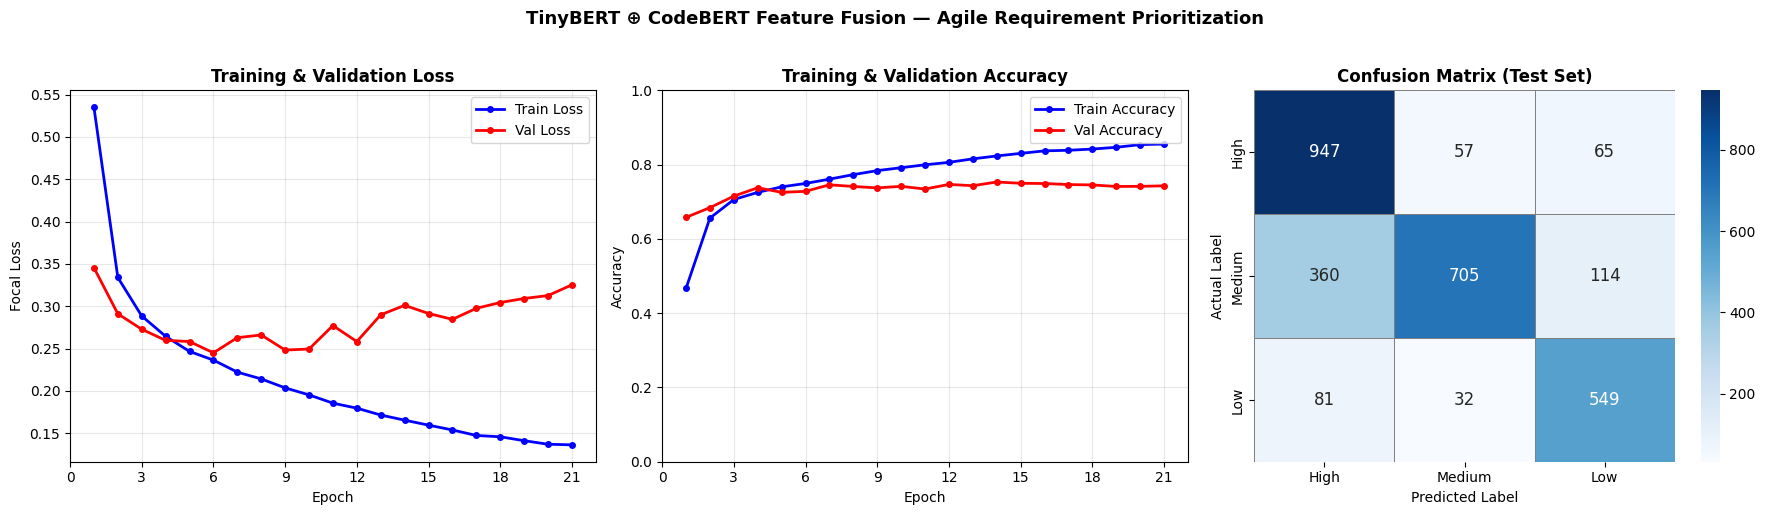

✅ Plots saved → fusion_results.png


In [11]:
#═══════════════════════════════════════════════════════════════
# STEP 11: Plot loss, accuracy, confusion matrix
#═══════════════════════════════════════════════════════════════
epochs_ran = len(history['train_loss'])
x          = range(1, epochs_ran + 1)

fig, axes  = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(
    "TinyBERT ⊕ CodeBERT Feature Fusion — Agile Requirement Prioritization",
    fontsize=13, fontweight='bold', y=1.02
)

# ── Loss ─────────────────────────────────────────────────────
axes[0].plot(x, history['train_loss'], 'b-o', markersize=4,
             linewidth=2, label='Train Loss')
axes[0].plot(x, history['val_loss'],   'r-o', markersize=4,
             linewidth=2, label='Val Loss')
axes[0].set_title('Training & Validation Loss', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Focal Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

# ── Accuracy ─────────────────────────────────────────────────
axes[1].plot(x, history['train_acc'], 'b-o', markersize=4,
             linewidth=2, label='Train Accuracy')
axes[1].plot(x, history['val_acc'],   'r-o', markersize=4,
             linewidth=2, label='Val Accuracy')
axes[1].set_title('Training & Validation Accuracy', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim([0, 1])
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

# ── Confusion Matrix ─────────────────────────────────────────
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels = ['High', 'Medium', 'Low'],
    yticklabels = ['High', 'Medium', 'Low'],
    ax          = axes[2],
    linewidths  = 0.5,
    linecolor   = 'gray',
    annot_kws   = {"size": 12}
)
axes[2].set_title('Confusion Matrix (Test Set)', fontweight='bold')
axes[2].set_xlabel('Predicted Label')
axes[2].set_ylabel('Actual Label')

plt.tight_layout()
plt.savefig("fusion_results.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plots saved → fusion_results.png")

In [13]:
#═══════════════════════════════════════════════════════════════
# STEP 12: Save everything — do this immediately!
# Saves: weights, config, metrics, predictions, history
#═══════════════════════════════════════════════════════════════
import shutil
from google.colab import drive, files as colab_files

drive.mount('/content/drive')
os.makedirs("./fusion_model_v2", exist_ok=True)

# ── Classifier weights ───────────────────────────────────────
torch.save(
    classifier.state_dict(),
    "./fusion_model_v2/classifier_weights.pt"
)

# ── Backbone finetuned weights ───────────────────────────────
torch.save(
    tinybert_model.state_dict(),
    "./fusion_model_v2/tinybert_finetuned.pt"
)
torch.save(
    codebert_model.state_dict(),
    "./fusion_model_v2/codebert_finetuned.pt"
)

# ── Config ───────────────────────────────────────────────────
config = {
    "tinybert_name" : TINYBERT_NAME,
    "codebert_name" : CODEBERT_NAME,
    "tinybert_dim"  : TINYBERT_DIM,
    "codebert_dim"  : CODEBERT_DIM,
    "fused_dim"     : FUSED_DIM,
    "num_classes"   : NUM_CLASSES,
    "max_length"    : MAX_LENGTH,
    "label_map"     : LABEL_MAP,
}
with open("./fusion_model_v2/config.json", "w") as f:
    json.dump(config, f, indent=2)

# ── Metrics ──────────────────────────────────────────────────
metrics = {
    "accuracy"        : round(acc,         4),
    "precision_macro" : round(precision,   4),
    "recall_macro"    : round(recall,      4),
    "f1_macro"        : round(macro_f1,    4),
    "f1_weighted"     : round(weighted_f1, 4),
    "best_val_macro"  : round(best_val_macro, 4),
}
with open("./fusion_model_v2/metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

# ── Training history ─────────────────────────────────────────
pd.DataFrame(history).to_csv(
    "./fusion_model_v2/training_history.csv", index=False
)

# ── Test predictions ─────────────────────────────────────────
pred_df = test_df.copy()
pred_df['predicted_label'] = [INV_LABEL[p] for p in all_preds]
pred_df['true_label']      = [INV_LABEL[l] for l in all_labels]
pred_df['prob_high']       = all_probs[:, 0].round(4)
pred_df['prob_medium']     = all_probs[:, 1].round(4)
pred_df['prob_low']        = all_probs[:, 2].round(4)
pred_df['correct']         = (
    pred_df['predicted_label'] == pred_df['true_label']
)
pred_df.to_csv("./fusion_model_v2/test_predictions.csv", index=False)

# ── Copy to Google Drive ─────────────────────────────────────
# ✅ FIXED: was "./fusion_model_v1" — now correctly "./fusion_model_v2"
shutil.copytree(
    "./fusion_model_v2",
    "/content/drive/MyDrive/fusion_model_v2",
    dirs_exist_ok=True
)
shutil.copy(
    "fusion_results.png",
    "/content/drive/MyDrive/fusion_results.png"
)

print("✅ All files saved to Google Drive/fusion_model_v2/")
print("   classifier_weights.pt")
print("   tinybert_finetuned.pt")
print("   codebert_finetuned.pt")
print("   config.json")
print("   metrics.json")
print("   training_history.csv")
print("   test_predictions.csv")
print("   fusion_results.png")

# ── Download to your computer ────────────────────────────────
colab_files.download("./fusion_model_v2/metrics.json")
colab_files.download("./fusion_model_v2/test_predictions.csv")
colab_files.download("fusion_results.png")

print("\n" + "=" * 65)
print("  RESEARCH SUMMARY")
print("=" * 65)
print(f"  Model    : TinyBERT({TINYBERT_DIM}) ⊕ CodeBERT({CODEBERT_DIM})")
print(f"  Task     : Agile Requirement Prioritization")
print(f"  Labels   : High / Medium / Low")
print(f"  Accuracy : {acc:.4f}")
print(f"  Macro F1 : {macro_f1:.4f}")
print("=" * 65)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ All files saved to Google Drive/fusion_model_v2/
   classifier_weights.pt
   tinybert_finetuned.pt
   codebert_finetuned.pt
   config.json
   metrics.json
   training_history.csv
   test_predictions.csv
   fusion_results.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


  RESEARCH SUMMARY
  Model    : TinyBERT(312) ⊕ CodeBERT(768)
  Task     : Agile Requirement Prioritization
  Labels   : High / Medium / Low
  Accuracy : 0.7564
  Macro F1 : 0.7585


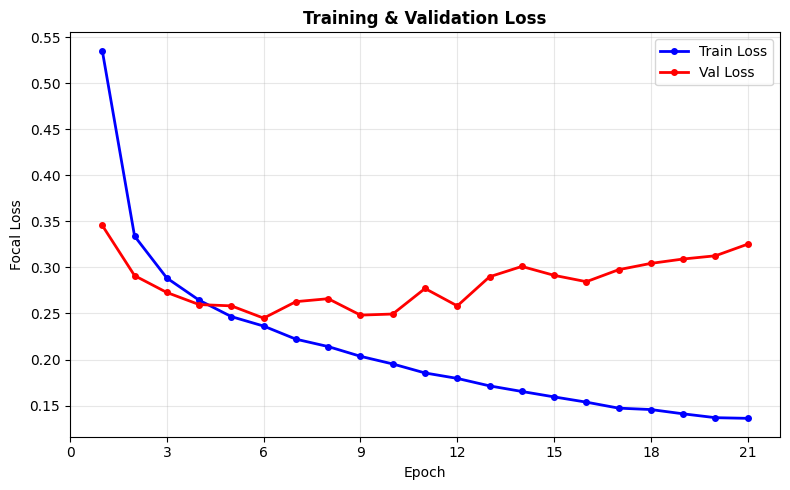

✅ Saved → loss_plot.png


In [14]:
#═══════════════════════════════════════════════════════════════
# STEP 11: Plot Loss
#═══════════════════════════════════════════════════════════════
epochs_ran = len(history['train_loss'])
x = range(1, epochs_ran + 1)

plt.figure(figsize=(8, 5))
plt.plot(x, history['train_loss'], 'b-o',
         markersize=4, linewidth=2, label='Train Loss')
plt.plot(x, history['val_loss'], 'r-o',
         markersize=4, linewidth=2, label='Val Loss')

plt.title('Training & Validation Loss', fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Focal Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.gca().xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

plt.tight_layout()
plt.savefig("loss_plot.png", dpi=150, bbox_inches='tight')
plt.show()

print("✅ Saved → loss_plot.png")

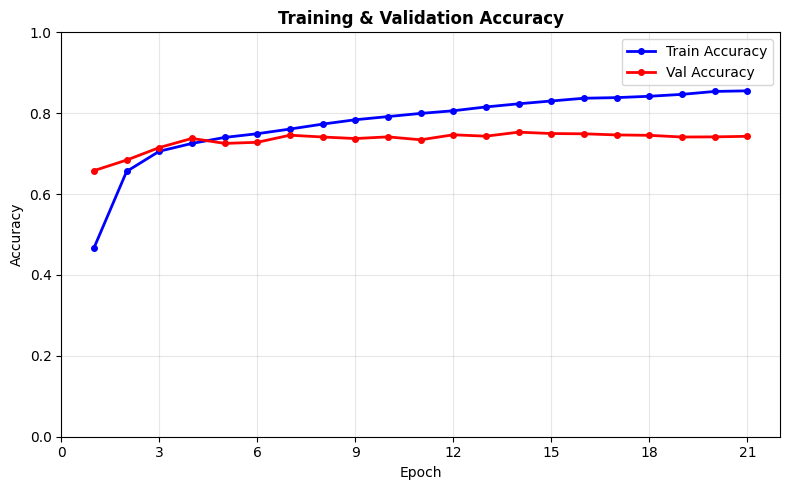

✅ Saved → accuracy_plot.png


In [15]:
#═══════════════════════════════════════════════════════════════
# STEP 12: Plot Accuracy
#═══════════════════════════════════════════════════════════════

plt.figure(figsize=(8, 5))
plt.plot(x, history['train_acc'], 'b-o',
         markersize=4, linewidth=2, label='Train Accuracy')
plt.plot(x, history['val_acc'], 'r-o',
         markersize=4, linewidth=2, label='Val Accuracy')

plt.title('Training & Validation Accuracy', fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0, 1])
plt.legend()
plt.grid(True, alpha=0.3)
plt.gca().xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

plt.tight_layout()
plt.savefig("accuracy_plot.png", dpi=150, bbox_inches='tight')
plt.show()

print("✅ Saved → accuracy_plot.png")

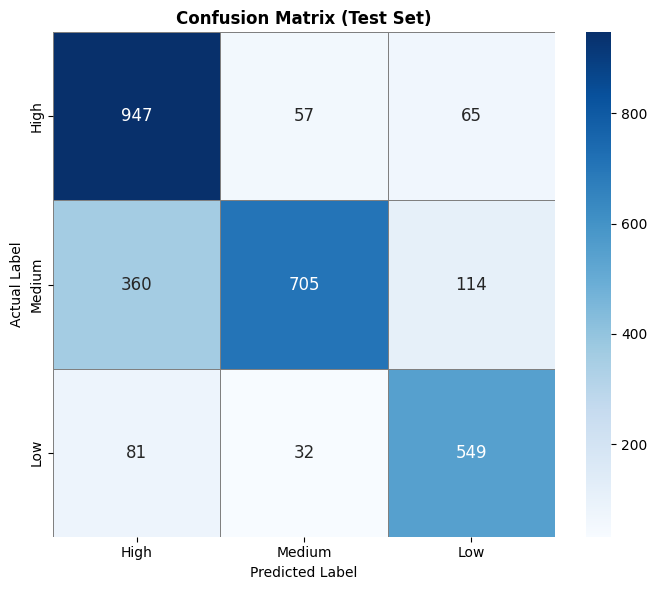

✅ Saved → confusion_matrix.png


In [16]:
#═══════════════════════════════════════════════════════════════
# STEP 13: Plot Confusion Matrix
#═══════════════════════════════════════════════════════════════

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['High', 'Medium', 'Low'],
    yticklabels=['High', 'Medium', 'Low'],
    linewidths=0.5,
    linecolor='gray',
    annot_kws={"size": 12}
)

plt.title('Confusion Matrix (Test Set)', fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')

plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches='tight')
plt.show()

print("✅ Saved → confusion_matrix.png")

In [17]:
#═══════════════════════════════════════════════════════════════
# STEP 13: Test model on unlabeled_dataset.csv
# 98 agile requirements, no labels
# Predicts priority + confidence for each requirement
#═══════════════════════════════════════════════════════════════
from google.colab import files as colab_files

print("Upload unlabeled_dataset.csv:")
uploaded     = colab_files.upload()
unlabeled_df = pd.read_csv(
    "unlabeled_dataset.csv",
    header = None,
    names  = ['text']
)

unlabeled_df = unlabeled_df.dropna(
    subset=['text']
).reset_index(drop=True)
unlabeled_df['text'] = unlabeled_df['text'].astype(str).str.strip()

print(f"\n✅ Loaded {len(unlabeled_df):,} requirements")
print("\nSample requirements:")
for i, row in unlabeled_df.head(3).iterrows():
    print(f"   [{i+1}] {row['text'][:75]}...")

# ── Set all models to eval ────────────────────────────────────
classifier.eval()
tinybert_model.eval()
codebert_model.eval()

def predict_single(text):
    tiny_enc = tinybert_tokenizer(
        text, max_length=MAX_LENGTH,
        padding='max_length', truncation=True,
        return_tensors='pt'
    )
    code_enc = codebert_tokenizer(
        text, max_length=MAX_LENGTH,
        padding='max_length', truncation=True,
        return_tensors='pt'
    )

    batch = {
        'tiny_input_ids'     : tiny_enc['input_ids'],
        'tiny_attention_mask': tiny_enc['attention_mask'],
        'code_input_ids'     : code_enc['input_ids'],
        'code_attention_mask': code_enc['attention_mask'],
        'label'              : torch.tensor([0])
    }

    tiny_emb, code_emb = extract_embeddings(batch, training=False)

    with torch.no_grad():
        with torch.cuda.amp.autocast():
            logits = classifier(tiny_emb, code_emb)

    probs      = torch.softmax(logits, dim=-1)[0].cpu().numpy()
    pred_id    = int(probs.argmax())
    confidence = round(float(probs[pred_id]) * 100, 2)

    return INV_LABEL[pred_id], confidence, {
        'prob_high'  : round(float(probs[0]) * 100, 2),
        'prob_medium': round(float(probs[1]) * 100, 2),
        'prob_low'   : round(float(probs[2]) * 100, 2),
    }

# ── Predict all ───────────────────────────────────────────────
print("\nRunning predictions...")
results = []
for idx, row in unlabeled_df.iterrows():
    priority, confidence, probs = predict_single(row['text'])
    results.append({
        'requirement_no' : idx + 1,
        'text'           : row['text'],
        'priority'       : priority,
        'confidence'     : confidence,
        'prob_high'      : probs['prob_high'],
        'prob_medium'    : probs['prob_medium'],
        'prob_low'       : probs['prob_low'],
    })

results_df = pd.DataFrame(results)

# Sort High → Medium → Low by confidence descending
priority_order       = {'High': 0, 'Medium': 1, 'Low': 2}
results_df['sort_p'] = results_df['priority'].map(priority_order)
results_df['sort_c'] = -results_df['confidence']
results_df           = results_df.sort_values(
                           ['sort_p', 'sort_c']
                       ).drop(
                           columns=['sort_p', 'sort_c']
                       ).reset_index(drop=True)
results_df.index      += 1
results_df.index.name  = 'rank'

# ── Print results ─────────────────────────────────────────────
print(f"\n{'Rank':<6} {'Priority':<10} {'Conf%':<8} Requirement")
print("-" * 85)
for idx, row in results_df.iterrows():
    emoji = {'High':'🔴','Medium':'🟡','Low':'🟢'}[row['priority']]
    print(f"{idx:<6} {emoji} {row['priority']:<8} "
          f"{row['confidence']:<8}  {row['text'][:60]}...")

# ── Summary ───────────────────────────────────────────────────
high_c   = len(results_df[results_df['priority']=='High'])
medium_c = len(results_df[results_df['priority']=='Medium'])
low_c    = len(results_df[results_df['priority']=='Low'])
avg_conf = results_df['confidence'].mean()

print("\n" + "=" * 85)
print("📊 PREDICTION SUMMARY")
print("=" * 85)
print(f"   Total          : {len(results_df)}")
print(f"   🔴 High        : {high_c}  ({high_c/len(results_df)*100:.1f}%)")
print(f"   🟡 Medium      : {medium_c}  ({medium_c/len(results_df)*100:.1f}%)")
print(f"   🟢 Low         : {low_c}  ({low_c/len(results_df)*100:.1f}%)")
print(f"   Avg confidence : {avg_conf:.2f}%")

# ── Sanity checks ─────────────────────────────────────────────
print("\n🔍 MODEL SANITY CHECK")
print("=" * 85)
print(f"   ✅ Ran on all {len(results_df)} requirements without error")
for cls in ['High', 'Medium', 'Low']:
    predicted = cls in results_df['priority'].values
    status    = "✅ predicted" if predicted else "⚠️  NEVER predicted"
    print(f"   {cls:<8} : {status}")

over_conf = len(results_df[results_df['confidence'] > 99.0])
if over_conf > len(results_df) * 0.8:
    print(f"\n   ⚠️  {over_conf}/{len(results_df)} are >99% confident")
    print(f"       May indicate overfitting")
else:
    print(f"\n   ✅ Confidence distribution looks healthy")
print("=" * 85)

# ── Save + download ───────────────────────────────────────────
results_df.to_csv("unlabeled_predictions.csv")
results_df.to_csv("/content/drive/MyDrive/unlabeled_predictions.csv")
colab_files.download("unlabeled_predictions.csv")

print(f"\n✅ Downloaded: unlabeled_predictions.csv")
print(f"🎯 Done! {len(results_df)} requirements predicted and ranked.")

Upload unlabeled_dataset.csv:


Saving unlabeled_dataset.csv to unlabeled_dataset.csv

✅ Loaded 98 requirements

Sample requirements:
   [1] As a Data user, I want to have the 12-19-2017 deletions processed....
   [2] As a UI designer, I want to redesign the Resources page, so that it matches...
   [3] As a UI designer, I want to report to the Agencies about user testing, so t...

Running predictions...


/tmp/ipykernel_2215/1453402884.py:54: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():



Rank   Priority   Conf%    Requirement
-------------------------------------------------------------------------------------
1      🔴 High     95.41     As an agency user, I want the FABS validation rules to accep...
2      🔴 High     95.31     As an Owner, I want to reset the environment to only take St...
3      🔴 High     95.17     As an agency user, I want to ensure that deleted FSRS record...
4      🔴 High     94.92     As an owner, I want to be sure that USAspending only send gr...
5      🔴 High     94.92     As an agency user, I want to be confident that the data comi...
6      🔴 High     94.04     As a user, I don't want to see NASA grants displayed as cont...
7      🔴 High     93.7      As a FABS user, I want to have read-only access to DABS, so ...
8      🔴 High     93.36     As a Broker user, I want to submit records for individual re...
9      🔴 High     91.99     As an agency user, I want the FABS validation rules to accep...
10     🔴 High     91.6      As a broker team m

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ Downloaded: unlabeled_predictions.csv
🎯 Done! 98 requirements predicted and ranked.
